<a href="https://colab.research.google.com/github/mayurda8/AI-powered-Industrial-Failure-Intelligence-System-IFIS-/blob/main/Industrial_Failure_Intelligence_System_(IFIS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/ai4i+2020+predictive+maintenance+dataset.zip')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [7]:
failure_cols = ['TWF','HDF','PWF','OSF','RNF']
df[failure_cols].sum()

,0
TWF,46
HDF,115
PWF,95
OSF,98
RNF,19


In [8]:
pd.crosstab(df['Type'], df['Machine failure'])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [9]:
numeric_df = df.drop(columns=['Product ID','Type'])
numeric_df.corr()['Machine failure'].sort_values(ascending=False)

,Machine failure
Machine failure,1.000000
HDF,0.575800
OSF,0.531083
PWF,0.522812
TWF,0.362904
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Process temperature [K],0.035946
RNF,0.004516


In [10]:
drop_cols = ['UDI','Product ID','TWF','HDF','PWF','OSF','RNF']
df = df.drop(columns=drop_cols)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [12]:
df['TSI'] = df['Process temperature [K]'] - df['Air temperature [K]']

In [13]:
df['MLI'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

In [14]:
df['WIS'] = df['Tool wear [min]'] * df['Torque [Nm]']

In [15]:
df['SSR'] = df['Rotational speed [rpm]'] / df['Torque [Nm]']

In [16]:
df = pd.get_dummies(df, columns=['Type'], drop_first=True)

In [17]:
df['CHI'] = (
    0.35 * df['TSI'] +
    0.30 * df['Torque [Nm]'] +
    0.20 * df['Tool wear [min]'] +
    0.15 * (df['MLI'] / 1000)
)

In [18]:
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TSI,MLI,WIS,SSR,Type_L,Type_M,CHI
0,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.0,36.238318,False,True,26.472420
1,298.2,308.7,1408,46.3,3,0,10.5,65190.4,138.9,30.410367,True,False,27.943560
2,298.1,308.5,1498,49.4,5,0,10.4,74001.2,247.0,30.323887,True,False,30.560180
3,298.2,308.6,1433,39.5,7,0,10.4,56603.5,276.5,36.278481,True,False,25.380525
4,298.2,308.7,1408,40.0,9,0,10.5,56320.0,360.0,35.200000,True,False,25.923000


In [19]:
df.corr()['Machine failure'].sort_values(ascending=False)

,Machine failure
Machine failure,1.000000
Torque [Nm],0.191321
WIS,0.190427
MLI,0.176039
CHI,0.158962
Tool wear [min],0.105448
Air temperature [K],0.082556
SSR,0.063317
Process temperature [K],0.035946
Type_L,0.035643


In [20]:
df.shape

(10000, 13)

In [21]:
df.corr()['Machine failure'].sort_values(ascending=False)

,Machine failure
Machine failure,1.000000
Torque [Nm],0.191321
WIS,0.190427
MLI,0.176039
CHI,0.158962
Tool wear [min],0.105448
Air temperature [K],0.082556
SSR,0.063317
Process temperature [K],0.035946
Type_L,0.035643


In [22]:
X = df.drop(columns=['Machine failure'])
y = df['Machine failure']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
!pip install imbalanced-learn

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [27]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.60      0.81      0.69        68

    accuracy                           0.97      2000
   macro avg       0.80      0.89      0.84      2000
weighted avg       0.98      0.97      0.98      2000



In [29]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[1895,   37],
       [  13,   55]])

In [30]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
8,SSR,0.151348
2,Rotational speed [rpm],0.148148
6,MLI,0.140820
3,Torque [Nm],0.134249
4,Tool wear [min],0.091953
5,TSI,0.077261
11,CHI,0.073660
7,WIS,0.069932
0,Air temperature [K],0.040918
9,Type_L,0.034823


In [31]:
!pip install xgboost

In [33]:
X_train_smote.columns = X_train_smote.columns.str.replace('[', '', regex=False)
X_train_smote.columns = X_train_smote.columns.str.replace(']', '', regex=False)
X_train_smote.columns = X_train_smote.columns.str.replace('<', '', regex=False)
X_train_smote.columns = X_train_smote.columns.str.replace(' ', '_')

X_test.columns = X_test.columns.str.replace('[', '', regex=False)
X_test.columns = X_test.columns.str.replace(']', '', regex=False)
X_test.columns = X_test.columns.str.replace('<', '', regex=False)
X_test.columns = X_test.columns.str.replace(' ', '_')

In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [35]:
y_pred_xgb = xgb.predict(X_test)

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.64      0.81      0.71        68

    accuracy                           0.98      2000
   macro avg       0.82      0.90      0.85      2000
weighted avg       0.98      0.98      0.98      2000



In [37]:
!pip install shap

In [38]:
import shap

In [39]:
explainer = shap.TreeExplainer(xgb)

In [40]:
shap_values = explainer.shap_values(X_test)

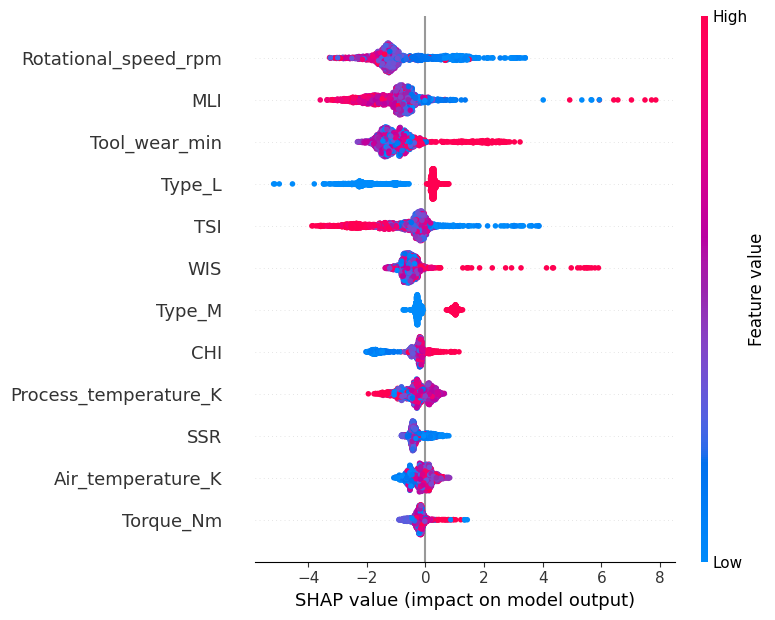

In [41]:
shap.summary_plot(shap_values, X_test)

In [43]:
shap.initjs()

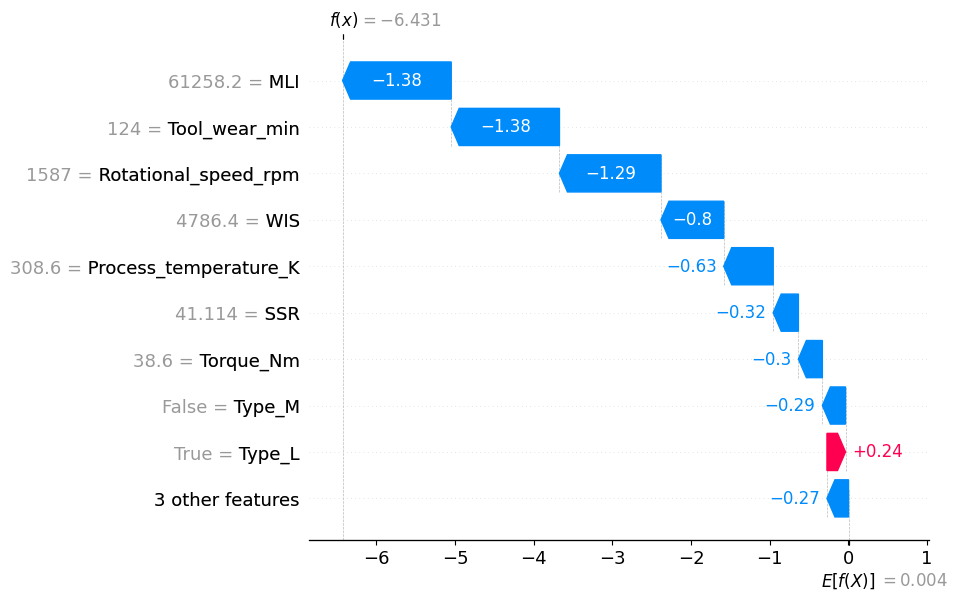

In [44]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

In [45]:
failure_probs = xgb.predict_proba(X_test)[:,1]

In [46]:
risk_df = X_test.copy()
risk_df['Failure_Probability'] = failure_probs
risk_df['Risk_Score'] = failure_probs * 100
risk_df['Prediction'] = y_pred_xgb

risk_df.head()

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,TSI,MLI,WIS,SSR,Type_L,Type_M,CHI,Failure_Probability,Risk_Score,Prediction
2997,300.5,309.8,1345,62.7,153,9.3,84331.5,9593.1,21.451356,True,False,65.314725,0.078946,7.894615,0
4871,303.7,312.4,1513,40.1,135,8.7,60671.3,5413.5,37.730673,True,False,51.175695,0.001290,0.129001,0
3858,302.5,311.4,1559,37.6,209,8.9,58618.4,7858.4,41.462766,True,False,64.987760,0.615018,61.501842,1
951,295.6,306.3,1509,35.8,60,10.7,54022.2,2148.0,42.150838,False,False,34.588330,0.001484,0.148357,0
6463,300.5,310.0,1358,60.4,102,9.5,82023.2,6160.8,22.483444,False,False,54.148480,0.023082,2.308243,0


In [47]:
import plotly.express as px

fig = px.histogram(
    risk_df,
    x='Risk_Score',
    nbins=30,
    title='Machine Risk Distribution'
)

fig.show()

In [48]:
top_risk = risk_df.sort_values(
    by='Risk_Score',
    ascending=False
).head(10)

top_risk[['Risk_Score']]

,Risk_Score
4342,99.979713
248,99.956589
6497,99.955780
249,99.944122
6078,99.943764
9664,99.943092
926,99.941170
2444,99.923775
6540,99.915550
4601,99.904686


In [49]:
fig = px.bar(
    top_risk,
    y='Risk_Score',
    title='Top 10 Critical Machines'
)

fig.show()

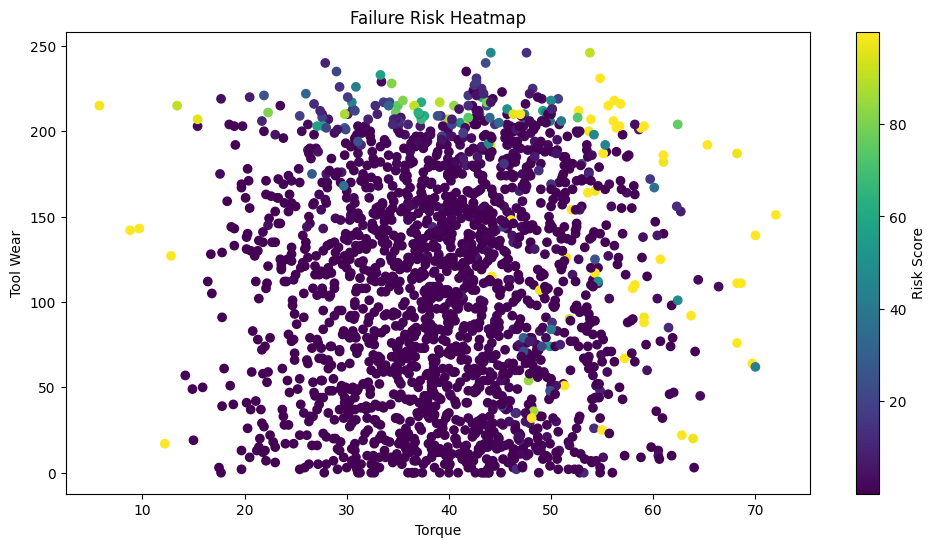

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.scatter(
    risk_df['Torque_Nm'],
    risk_df['Tool_wear_min'],
    c=risk_df['Risk_Score']
)
plt.colorbar(label='Risk Score')
plt.xlabel('Torque')
plt.ylabel('Tool Wear')
plt.title('Failure Risk Heatmap')
plt.show()

In [51]:
def classify_risk(score):
    if score >= 70:
        return 'Critical'
    elif score >= 40:
        return 'High'
    elif score >= 20:
        return 'Moderate'
    else:
        return 'Low'

risk_df['Risk_Level'] = risk_df['Risk_Score'].apply(classify_risk)

risk_df['Risk_Level'].value_counts()

,count
Risk_Level,
Low,1869
Critical,72
Moderate,33
High,26


In [52]:
top_risk_indices = top_risk.index
y_test.loc[top_risk_indices]

,Machine failure
4342,1
248,1
6497,1
249,1
6078,1
9664,1
926,1
2444,1
6540,1
4601,1
